# Phase 2: Realistic Speech Tasks — Hidden-Layer Perturbation Results

This notebook visualises the results of the Phase 2 realistic experiments (SHD & SSC).  
At test time, a fraction **f** of hidden-layer spikes are replaced with random spikes (preserving spike count per neuron).  
- **f = 0**: hidden output untouched (full temporal code available).  
- **f = 1**: all temporal structure destroyed (rate-only internal signal).

Two model variants are compared:
- **SGD** — baseline SNN without learnable axonal delays.
- **SGD-delay** — SNN with learnable axonal delays after each hidden layer.

Three dataset variants are tested:
- **Whole** — full spike trains (both rate and temporal information).
- **Part** — partial spike trains (reduced rate information).
- **Norm** — rate-normalised spike trains (zero rate information in input).

In [1]:
import json
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl

# ---------- global style ----------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
})

BASE = pathlib.Path(".")  # notebook lives in code/realistic/

## Example Spike Rasters: SHD & SSC Dataset Variants

Each auditory dataset is preprocessed into three variants that progressively remove rate-based information while retaining temporal structure:
- **Whole (raw)** — the original spike train, containing both firing-rate and spike-timing cues.
- **Part (filtered)** — neuron selection and spike filtering reduce rate information.
- **Norm (min-count)** — spike-count normalisation removes all rate differences; only relative timing remains.

The figure below shows one example sample from each variant for SHD (top row) and SSC (bottom row).

In [ ]:
import scipy.io as sio
import h5py

# ---------- Load SHD data (.mat) ----------
shd_data_dir = BASE / "shd/shd_data"
shd_whole_X = sio.loadmat(shd_data_dir / "shd_whole.mat")["X"]
shd_whole_Y = sio.loadmat(shd_data_dir / "shd_whole.mat")["Y"].ravel()
shd_part_X = sio.loadmat(shd_data_dir / "shd_part_new.mat")["X"]
shd_part_Y = sio.loadmat(shd_data_dir / "shd_part_new.mat")["Y"].ravel()
shd_norm_X = sio.loadmat(shd_data_dir / "shd_norm_new.mat")["X"]
shd_norm_Y = sio.loadmat(shd_data_dir / "shd_norm_new.mat")["Y"].ravel()

# ---------- Load SSC data (.h5) ----------
ssc_data_dir = BASE / "ssc/ssc_data"
with h5py.File(ssc_data_dir / "ssc_whole.h5", "r") as f:
    ssc_whole_X, ssc_whole_Y = f["X"][:], f["Y"][:].ravel()
with h5py.File(ssc_data_dir / "ssc_part.h5", "r") as f:
    ssc_part_X, ssc_part_Y = f["X"][:], f["Y"][:].ravel()
with h5py.File(ssc_data_dir / "ssc_norm.h5", "r") as f:
    ssc_norm_X, ssc_norm_Y = f["X"][:], f["Y"][:].ravel()

# ---------- Pick a fixed sample index for reproducibility ----------
# Variants are filtered subsets with different sizes, so bound by the minimum.
np.random.seed(42)
shd_min_len = min(len(shd_whole_Y), len(shd_part_Y), len(shd_norm_Y))
ssc_min_len = min(len(ssc_whole_Y), len(ssc_part_Y), len(ssc_norm_Y))
shd_idx = np.random.randint(shd_min_len)
ssc_idx = np.random.randint(ssc_min_len)

# ---------- Plot: 2 rows (SHD, SSC) x 3 columns (Whole, Part, Norm) ----------
fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex="row", sharey="row")

datasets = [
    # (row, col, spike_train, title)
    (0, 0, shd_whole_X[shd_idx], "Whole (raw)"),
    (0, 1, shd_part_X[shd_idx],  "Part (filtered)"),
    (0, 2, shd_norm_X[shd_idx],  "Norm (min-count)"),
    (1, 0, ssc_whole_X[ssc_idx], "Whole (raw)"),
    (1, 1, ssc_part_X[ssc_idx],  "Part (filtered)"),
    (1, 2, ssc_norm_X[ssc_idx],  "Norm (min-count)"),
]

for row, col, spike_train, title in datasets:
    ax = axes[row, col]
    neuron_idxs, time_idxs = np.where(spike_train == 1)
    ax.scatter(time_idxs, neuron_idxs, s=0.3, c="black", marker=".", linewidths=0, rasterized=True)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlim(0, spike_train.shape[1])
    ax.set_ylim(0, spike_train.shape[0])

# Row labels
axes[0, 0].set_ylabel("SHD\nNeuron Index")
axes[1, 0].set_ylabel("SSC\nNeuron Index")

for ax in axes[1, :]:
    ax.set_xlabel("Time Step")

fig.tight_layout()
#plt.savefig("shd_ssc_data_rasters.png", dpi=300, bbox_inches="tight")
plt.show()

## SHD & SSC — Accuracy vs Hidden-Layer Perturbation

Each panel shows how test accuracy degrades as the fraction **f** of randomised hidden-layer spikes increases.  
Solid lines (**SGD-delay**) and dashed lines (**SGD**) are plotted for each dataset variant (Whole, Part, Norm).  
A steeper drop indicates stronger reliance on temporal structure in the hidden representation.

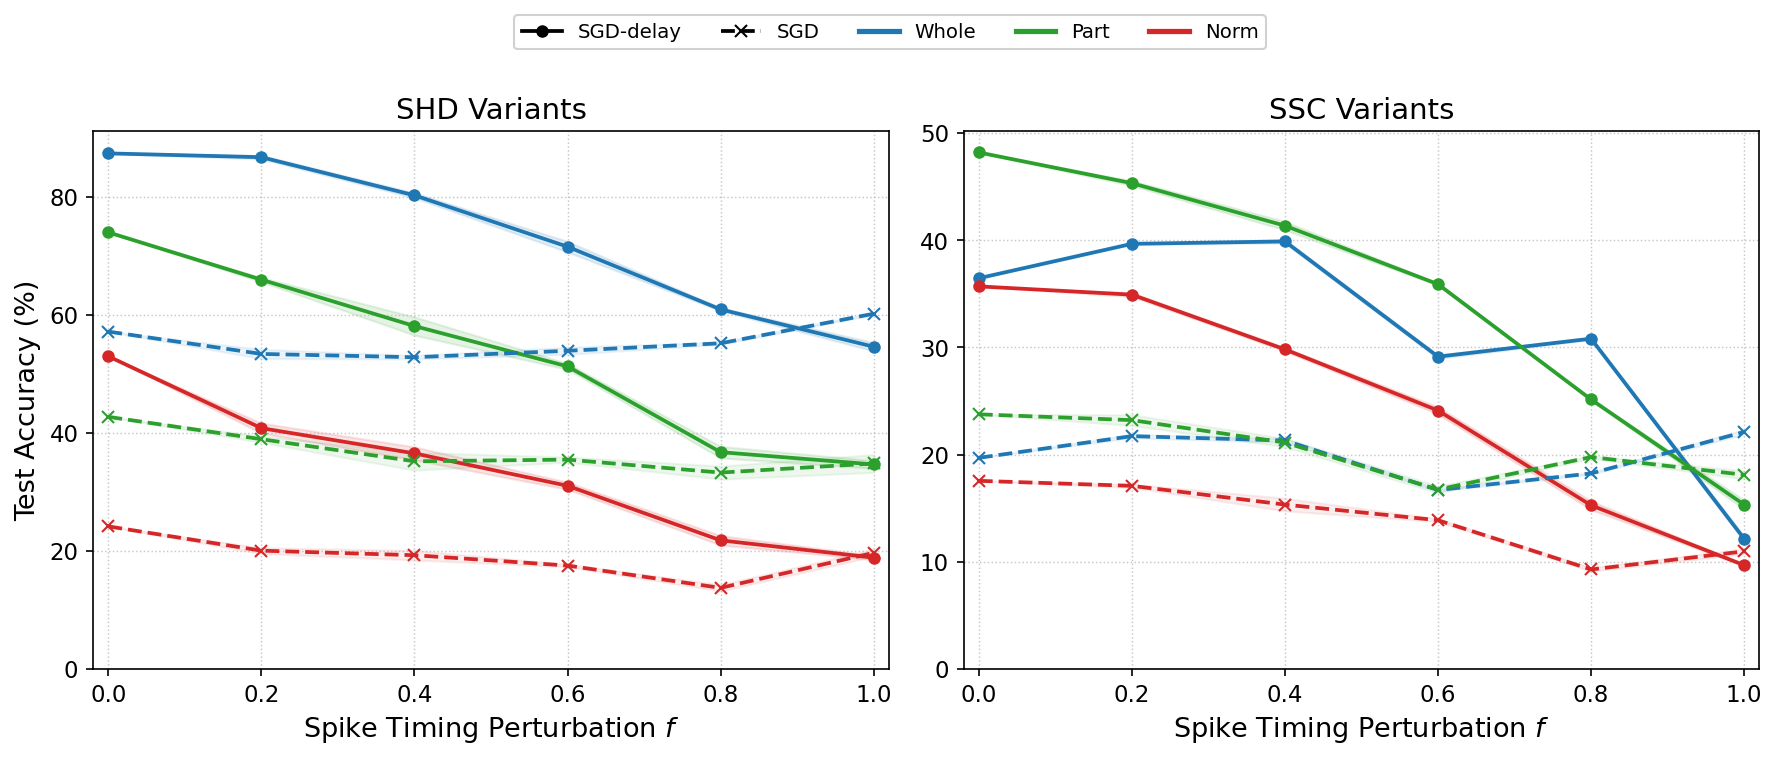

In [2]:
def load_results(path: pathlib.Path) -> tuple:
    """Load a perturbation results JSON and return (f_values, means, stds)."""
    with open(path) as fh:
        raw = json.load(fh)
    f_vals = sorted(float(k) for k in raw)
    means = np.array([raw[str(f) if str(f) in raw else f"{f:.1f}"]["mean"] for f in f_vals]) * 100
    stds = np.array([raw[str(f) if str(f) in raw else f"{f:.1f}"]["std"] for f in f_vals]) * 100
    return f_vals, means, stds


# ---------- Load SHD results ----------
SHD_LOG = BASE / "shd/log"
shd_whole_del_f, shd_whole_del_mean, shd_whole_del_std = load_results(SHD_LOG / "shd_whole_delay_hidden_perturbation_results.json")
shd_whole_nod_f, shd_whole_nod_mean, shd_whole_nod_std = load_results(SHD_LOG / "shd_whole_nodelay_hidden_perturbation_results.json")
shd_part_del_f, shd_part_del_mean, shd_part_del_std = load_results(SHD_LOG / "shd_part_delay_hidden_perturbation_results.json")
shd_part_nod_f, shd_part_nod_mean, shd_part_nod_std = load_results(SHD_LOG / "shd_part_nodelay_hidden_perturbation_results.json")
shd_norm_del_f, shd_norm_del_mean, shd_norm_del_std = load_results(SHD_LOG / "shd_norm_delay_hidden_perturbation_results.json")
shd_norm_nod_f, shd_norm_nod_mean, shd_norm_nod_std = load_results(SHD_LOG / "shd_norm_nodelay_hidden_perturbation_results.json")

# ---------- Load SSC results ----------
SSC_LOG = BASE / "ssc/log"
ssc_whole_del_f, ssc_whole_del_mean, ssc_whole_del_std = load_results(SSC_LOG / "ssc_whole_delay_hidden_perturbation_results.json")
ssc_whole_nod_f, ssc_whole_nod_mean, ssc_whole_nod_std = load_results(SSC_LOG / "ssc_whole_nodelay_hidden_perturbation_results.json")
ssc_part_del_f, ssc_part_del_mean, ssc_part_del_std = load_results(SSC_LOG / "ssc_part_delay_hidden_perturbation_results.json")
ssc_part_nod_f, ssc_part_nod_mean, ssc_part_nod_std = load_results(SSC_LOG / "ssc_part_nodelay_hidden_perturbation_results.json")
ssc_norm_del_f, ssc_norm_del_mean, ssc_norm_del_std = load_results(SSC_LOG / "ssc_norm_delay_hidden_perturbation_results.json")
ssc_norm_nod_f, ssc_norm_nod_mean, ssc_norm_nod_std = load_results(SSC_LOG / "ssc_norm_nodelay_hidden_perturbation_results.json")

# ---------- Colours & markers (matching reference image) ----------
COLORS = {"Whole": "#1f77b4", "Part": "#2ca02c", "Norm": "#d62728"}  # blue, green, red

fig, (ax_shd, ax_ssc) = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

# ==================== SHD panel ====================
# SGD-delay (solid, circle marker)
ax_shd.plot(shd_whole_del_f, shd_whole_del_mean, "o-", color=COLORS["Whole"], markersize=5, linewidth=1.8)
ax_shd.fill_between(shd_whole_del_f, shd_whole_del_mean - shd_whole_del_std, shd_whole_del_mean + shd_whole_del_std, color=COLORS["Whole"], alpha=0.12)

ax_shd.plot(shd_part_del_f, shd_part_del_mean, "o-", color=COLORS["Part"], markersize=5, linewidth=1.8)
ax_shd.fill_between(shd_part_del_f, shd_part_del_mean - shd_part_del_std, shd_part_del_mean + shd_part_del_std, color=COLORS["Part"], alpha=0.12)

ax_shd.plot(shd_norm_del_f, shd_norm_del_mean, "o-", color=COLORS["Norm"], markersize=5, linewidth=1.8)
ax_shd.fill_between(shd_norm_del_f, shd_norm_del_mean - shd_norm_del_std, shd_norm_del_mean + shd_norm_del_std, color=COLORS["Norm"], alpha=0.12)

# SGD / nodelay (dashed, X marker)
ax_shd.plot(shd_whole_nod_f, shd_whole_nod_mean, "x--", color=COLORS["Whole"], markersize=6, linewidth=1.8)
ax_shd.fill_between(shd_whole_nod_f, shd_whole_nod_mean - shd_whole_nod_std, shd_whole_nod_mean + shd_whole_nod_std, color=COLORS["Whole"], alpha=0.08)

ax_shd.plot(shd_part_nod_f, shd_part_nod_mean, "x--", color=COLORS["Part"], markersize=6, linewidth=1.8)
ax_shd.fill_between(shd_part_nod_f, shd_part_nod_mean - shd_part_nod_std, shd_part_nod_mean + shd_part_nod_std, color=COLORS["Part"], alpha=0.08)

ax_shd.plot(shd_norm_nod_f, shd_norm_nod_mean, "x--", color=COLORS["Norm"], markersize=6, linewidth=1.8)
ax_shd.fill_between(shd_norm_nod_f, shd_norm_nod_mean - shd_norm_nod_std, shd_norm_nod_mean + shd_norm_nod_std, color=COLORS["Norm"], alpha=0.08)

ax_shd.set_title("SHD Variants")
ax_shd.set_xlabel("Spike Timing Perturbation $f$")
ax_shd.set_ylabel("Test Accuracy (%)")
ax_shd.set_xlim(-0.02, 1.02)
ax_shd.set_ylim(0, None)
ax_shd.set_ylim(0, None)
ax_shd.grid(True, linestyle=':', linewidth=0.7, alpha=0.7)

# ==================== SSC panel ====================
# SGD-delay (solid, circle marker)
ax_ssc.plot(ssc_whole_del_f, ssc_whole_del_mean, "o-", color=COLORS["Whole"], markersize=5, linewidth=1.8)
ax_ssc.fill_between(ssc_whole_del_f, ssc_whole_del_mean - ssc_whole_del_std, ssc_whole_del_mean + ssc_whole_del_std, color=COLORS["Whole"], alpha=0.12)

ax_ssc.plot(ssc_part_del_f, ssc_part_del_mean, "o-", color=COLORS["Part"], markersize=5, linewidth=1.8)
ax_ssc.fill_between(ssc_part_del_f, ssc_part_del_mean - ssc_part_del_std, ssc_part_del_mean + ssc_part_del_std, color=COLORS["Part"], alpha=0.12)

ax_ssc.plot(ssc_norm_del_f, ssc_norm_del_mean, "o-", color=COLORS["Norm"], markersize=5, linewidth=1.8)
ax_ssc.fill_between(ssc_norm_del_f, ssc_norm_del_mean - ssc_norm_del_std, ssc_norm_del_mean + ssc_norm_del_std, color=COLORS["Norm"], alpha=0.12)

# SGD / nodelay (dashed, X marker)
ax_ssc.plot(ssc_whole_nod_f, ssc_whole_nod_mean, "x--", color=COLORS["Whole"], markersize=6, linewidth=1.8)
ax_ssc.fill_between(ssc_whole_nod_f, ssc_whole_nod_mean - ssc_whole_nod_std, ssc_whole_nod_mean + ssc_whole_nod_std, color=COLORS["Whole"], alpha=0.08)

ax_ssc.plot(ssc_part_nod_f, ssc_part_nod_mean, "x--", color=COLORS["Part"], markersize=6, linewidth=1.8)
ax_ssc.fill_between(ssc_part_nod_f, ssc_part_nod_mean - ssc_part_nod_std, ssc_part_nod_mean + ssc_part_nod_std, color=COLORS["Part"], alpha=0.08)

ax_ssc.plot(ssc_norm_nod_f, ssc_norm_nod_mean, "x--", color=COLORS["Norm"], markersize=6, linewidth=1.8)
ax_ssc.fill_between(ssc_norm_nod_f, ssc_norm_nod_mean - ssc_norm_nod_std, ssc_norm_nod_mean + ssc_norm_nod_std, color=COLORS["Norm"], alpha=0.08)

ax_ssc.set_title("SSC Variants")
ax_ssc.set_xlabel("Spike Timing Perturbation $f$")
ax_ssc.set_xlim(-0.02, 1.02)
ax_ssc.set_ylim(0, None)
ax_ssc.set_ylim(0, None)
ax_ssc.grid(True, linestyle=':', linewidth=0.7, alpha=0.7)

# ==================== Shared legend ====================
# Model-type handles (black, style only)
h_delay = mlines.Line2D([], [], color="black", marker="o", linestyle="-", markersize=5, linewidth=1.8, label="SGD-delay")
h_nodelay = mlines.Line2D([], [], color="black", marker="x", linestyle="--", markersize=6, linewidth=1.8, label="SGD")

# Dataset-variant handles (colour only)
h_whole = mlines.Line2D([], [], color=COLORS["Whole"], linewidth=2.5, label="Whole")
h_part = mlines.Line2D([], [], color=COLORS["Part"], linewidth=2.5, label="Part")
h_norm = mlines.Line2D([], [], color=COLORS["Norm"], linewidth=2.5, label="Norm")

fig.legend(
    handles=[h_delay, h_nodelay, h_whole, h_part, h_norm],
    loc="upper center",
    ncol=5,
    framealpha=0.9,
    bbox_to_anchor=(0.5, 1.02),
)

fig.tight_layout(rect=[0, 0, 1, 0.93])
#plt.savefig("shd_ssc_hidden_perturbation.png", dpi=300, bbox_inches="tight")
plt.show()